# 0. Title + How to Use: ThaiChar72 Character Recognition

## Overview & Usage Modes
This notebook provides a self-contained, reproducible pipeline for 72-class Thai handwritten character recognition. It supports two primary execution workflows configured in **Section 2 (Config Cell)**:

1. **INFERENCE-ONLY MODE (`MODE = "inference"`, Default)**:
   - Loads the pre-trained model weights (`WEIGHTS_PATH`).
   - Evaluates Top-1 accuracy, balanced accuracy, Macro-F1, and minority class accuracy on both the stratified validation split and document-disjoint split.
   - Computes logit adjustment tau sweeps and plots a 72x72 confusion matrix using the Sarabun Thai font (`assets/fonts/Sarabun-Regular.ttf`).
   - Runs interactive glyph prediction (random validation samples, image file upload, and Gradio/ipywidgets interface).
   - Executes a corruption robustness sweep and exports summary metrics to `OUTPUT_DIR`.
   - **Zero raw dataset required**: Runs top-to-bottom without touching `DATA_ZIP` if pre-trained weights and cache exist.

2. **TRAINING MODE (`MODE = "train"`)**:
   - Checks and unzips raw data (`DATA_ZIP` -> `round2`) with Python `zipfile`.
   - Validates class counts across all 72 classes (asserting 62,707 total raw images).
   - Builds clean indices and train/val splits if missing.
   - Trains the winning recipe (`FINAL_CONFIG`: ResNet-18 @ 64px) using AdamW, Cosine Annealing, and EMA.
   - Logs metrics per epoch, plots training curves, and saves `best.pt` to `WEIGHTS_PATH`.
   - Optional 3-seed training loop (`RUN_SEEDS = [42, 0, 1]`) to evaluate mean ± std variance.

---

### Group Information Placeholder
- **Course / Project**: Thai Character Recognition (72 Classes)
- **Team**: Deep_CNN Research Team
- **Members**:
  - Member 1: Name (Student ID: XXXXXXXX)
  - Member 2: Name (Student ID: XXXXXXXX)
  - Member 3: Name (Student ID: XXXXXXXX)


## 1. Environment
This section inspects the runtime environment (Python, PyTorch, CUDA, GPU model), installs required dependencies if missing (`timm`, `opencv-python-headless`, `pyyaml`, `tabulate`, `imagehash`), mounts Google Drive (only when `USE_DRIVE=True`), clones/pulls project code if needed, and sets `sys.path.insert(0, "src")`.


In [1]:
import sys
import os
import platform
import subprocess
from pathlib import Path

# 1. Print runtime & hardware specifications
print("=" * 60)
print("System & Runtime Environment")
print("=" * 60)
print(f"Python Version:   {platform.python_version()}")

try:
    import torch
    print(f"PyTorch Version:  {torch.__version__}")
    cuda_avail = torch.cuda.is_available()
    print(f"CUDA Available:   {cuda_avail}")
    if cuda_avail:
        print(f"GPU Device:       {torch.cuda.get_device_name(0)}")
        print(f"Device Count:     {torch.cuda.device_count()}")
    else:
        print("Running on CPU (CUDA unavailable)")
except ImportError:
    print("PyTorch not yet imported; will be checked with dependencies.")

# 2. Install required packages quietly if not already importable
required_pkgs = [
    ("timm", "timm"),
    ("cv2", "opencv-python-headless"),
    ("yaml", "pyyaml"),
    ("tabulate", "tabulate"),
    ("imagehash", "imagehash"),
]

to_install = []
for mod_name, pip_name in required_pkgs:
    try:
        __import__(mod_name)
    except ImportError:
        to_install.append(pip_name)

if to_install:
    print(f"Installing missing packages: {to_install}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
    print("✓ Missing packages installed successfully.")
else:
    print("✓ All required packages (timm, cv2, pyyaml, tabulate, imagehash) are available.")

# 3. Mount Google Drive only if USE_DRIVE is True (defensive try/except)
USE_DRIVE = globals().get("USE_DRIVE", False)
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("✓ Google Drive mounted at /content/drive.")
    except Exception as e:
        print(f"Notice: Google Drive mount bypassed or running locally ({e}).")

# 4. Clone or pull project code if running in Colab or external environment
REPO_URL = globals().get("REPO_URL", "")
CODE_ZIP = globals().get("CODE_ZIP", "")

if REPO_URL:
    target_dir = Path("/content/thaichar")
    if target_dir.exists():
        print(f"Repository directory {target_dir} exists; pulling latest...")
        subprocess.run(["git", "-C", str(target_dir), "pull"], check=False)
    else:
        print(f"Cloning {REPO_URL} into {target_dir}...")
        subprocess.run(["git", "clone", REPO_URL, str(target_dir)], check=False)
    if target_dir.exists():
        os.chdir(str(target_dir))
elif CODE_ZIP and Path(CODE_ZIP).exists():
    import zipfile
    target_dir = Path("/content/thaichar")
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(CODE_ZIP, "r") as z:
        z.extractall(target_dir)
    os.chdir(str(target_dir))

# 5. Resolve repo root and insert src/ into sys.path
cwd = Path(".").resolve()
if (cwd / "src" / "thaichar").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src" / "thaichar").exists():
    REPO_ROOT = cwd.parent
elif Path("/content/thaichar/src/thaichar").exists():
    REPO_ROOT = Path("/content/thaichar")
else:
    REPO_ROOT = cwd

src_dir = str(REPO_ROOT / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
print(f"✓ Python path configured. REPO_ROOT={REPO_ROOT}, sys.path[0]={src_dir}")


System & Runtime Environment
Python Version:   3.12.13


PyTorch Version:  2.14.0+cpu
CUDA Available:   False
Running on CPU (CUDA unavailable)


/home/eggchad/eakject/research/Deep_Man/Deep_CNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All required packages (timm, cv2, pyyaml, tabulate, imagehash) are available.
✓ Python path configured. REPO_ROOT=/home/eggchad/eakject/research/Deep_Man/Deep_CNN, sys.path[0]=/home/eggchad/eakject/research/Deep_Man/Deep_CNN/src


## 2. Configuration
This is the **ONLY** cell defining paths and global runtime options. All subsequent cells consume these variables.


In [2]:
# ---- INJECTED BY run_notebook_local.py ----
MODE = 'inference'
USE_DRIVE = False
WEIGHTS_PATH = __import__('pathlib').Path('/home/eggchad/eakject/research/Deep_Man/Deep_CNN/runs/A1_resnet18_full_64_T4/best.pt')
PROJECT_DIR = __import__('pathlib').Path('/home/eggchad/eakject/research/Deep_Man/Deep_CNN')
# ---- END INJECTION ----

from pathlib import Path
import os

# ===========================================================================
# Configuration Cell: Centralized paths, run mode, and execution parameters
# ===========================================================================

# 1. Execution Mode: "inference" (default, skip training) or "train"
MODE = "inference"  # "inference" | "train"

# 2. Google Drive setting (set True when running in Colab with Drive assets)
USE_DRIVE = False

# Mount drive immediately if enabled here
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", exist_ok=True)
        print("✓ Google Drive mounted.")
    except Exception as e:
        print(f"Drive mount notice: {e}")

# 3. Project root directory
PROJECT_DIR = REPO_ROOT if "REPO_ROOT" in globals() else Path(".").resolve()
if not (PROJECT_DIR / "src" / "thaichar").exists() and (PROJECT_DIR.parent / "src" / "thaichar").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# 4. Dataset paths: ZIP archive and unpacked directory
# If using Drive: Path("/content/drive/MyDrive/ThaiCharacter Dataset.zip")
DATA_ZIP = (
    Path("/content/drive/MyDrive/ThaiCharacter Dataset.zip")
    if USE_DRIVE
    else PROJECT_DIR / "data" / "ThaiCharacter Dataset.zip"
)
DATA_DIR = PROJECT_DIR / "data"

# 5. Training recipe configuration: default configs/final.yaml if exists, else A1_resnet18_full_64.yaml
FINAL_CONFIG = PROJECT_DIR / "configs" / "final.yaml"
if not FINAL_CONFIG.exists():
    FINAL_CONFIG = PROJECT_DIR / "configs" / "matrix" / "A1_resnet18_full_64.yaml"

# 6. Weights path: checks pre-trained checkpoints in runs/ or weights/
WEIGHTS_PATH = PROJECT_DIR / "runs" / "A1_resnet18_full_64_T4" / "best.pt"
if not WEIGHTS_PATH.exists():
    for candidate in [
        PROJECT_DIR / "weights" / "best.pt",
        PROJECT_DIR / "runs" / "final" / "best.pt",
        PROJECT_DIR / "best.pt",
    ]:
        if candidate.exists():
            WEIGHTS_PATH = candidate
            break

# 7. Output directory for exported metrics, plots, and figures
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 8. Training hyperparameters overrides
SEED = 42
EPOCHS_OVERRIDE = None  # None uses config epochs (e.g. 6); set to an int (e.g. 1) to override

print("=" * 60)
print("Active Configuration")
print("=" * 60)
print(f"MODE:            {MODE}")
print(f"USE_DRIVE:       {USE_DRIVE}")
print(f"PROJECT_DIR:     {PROJECT_DIR}")
print(f"DATA_ZIP:        {DATA_ZIP} (exists: {DATA_ZIP.exists()})")
print(f"DATA_DIR:        {DATA_DIR} (exists: {DATA_DIR.exists()})")
print(f"FINAL_CONFIG:    {FINAL_CONFIG} (exists: {FINAL_CONFIG.exists()})")
print(f"WEIGHTS_PATH:    {WEIGHTS_PATH} (exists: {WEIGHTS_PATH.exists()})")
print(f"OUTPUT_DIR:      {OUTPUT_DIR}")
print(f"SEED:            {SEED}")
print(f"EPOCHS_OVERRIDE: {EPOCHS_OVERRIDE}")


Active Configuration
MODE:            inference
USE_DRIVE:       False
PROJECT_DIR:     /home/eggchad/eakject/research/Deep_Man/Deep_CNN
DATA_ZIP:        /home/eggchad/eakject/research/Deep_Man/Deep_CNN/data/ThaiCharacter Dataset.zip (exists: False)
DATA_DIR:        /home/eggchad/eakject/research/Deep_Man/Deep_CNN/data (exists: True)
FINAL_CONFIG:    /home/eggchad/eakject/research/Deep_Man/Deep_CNN/configs/matrix/A1_resnet18_full_64.yaml (exists: True)
WEIGHTS_PATH:    /home/eggchad/eakject/research/Deep_Man/Deep_CNN/runs/A1_resnet18_full_64_T4/best.pt (exists: True)
OUTPUT_DIR:      /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs
SEED:            42
EPOCHS_OVERRIDE: None


## 3. Data Preparation and Inspection
This section checks for extracted raw images (`DATA_DIR/round2`), unzips `DATA_ZIP` using Python's `zipfile` if necessary (avoiding Windows extraction encoding bugs), tallies per-class counts in a 72-row table, asserts 62,707 total files (warning without crashing if mismatched), runs EDA/splitting only if `data/splits/split_seed42.csv` is missing, and displays distribution & montage figures if present.


Notice: Raw image folder '/home/eggchad/eakject/research/Deep_Man/Deep_CNN/data/round2' not found.
✓ Running in inference mode: raw dataset is optional when using pre-computed cache or shipped weights.

--- Per-Class File Counts (72 Classes, Total: 62,707) ---
|   code | char   | category   |   count |
|--------|--------|------------|---------|
|    161 | ก      | consonant  |    1951 |
|    162 | ข      | consonant  |    1355 |
|    163 | ฃ      | consonant  |       1 |
|    164 | ค      | consonant  |    1448 |
|    167 | ง      | consonant  |    1078 |
|    168 | จ      | consonant  |    1202 |
|    169 | ฉ      | consonant  |      43 |
|    170 | ช      | consonant  |    1013 |
|    171 | ซ      | consonant  |     295 |
|    173 | ญ      | consonant  |     113 |
... (72 classes total) ...

✓ Total raw file count matches expected: 62,707 images.
✓ Split file already present: /home/eggchad/eakject/research/Deep_Man/Deep_CNN/data/splits/split_seed42.csv. Skipping EDA and prep_data.

D

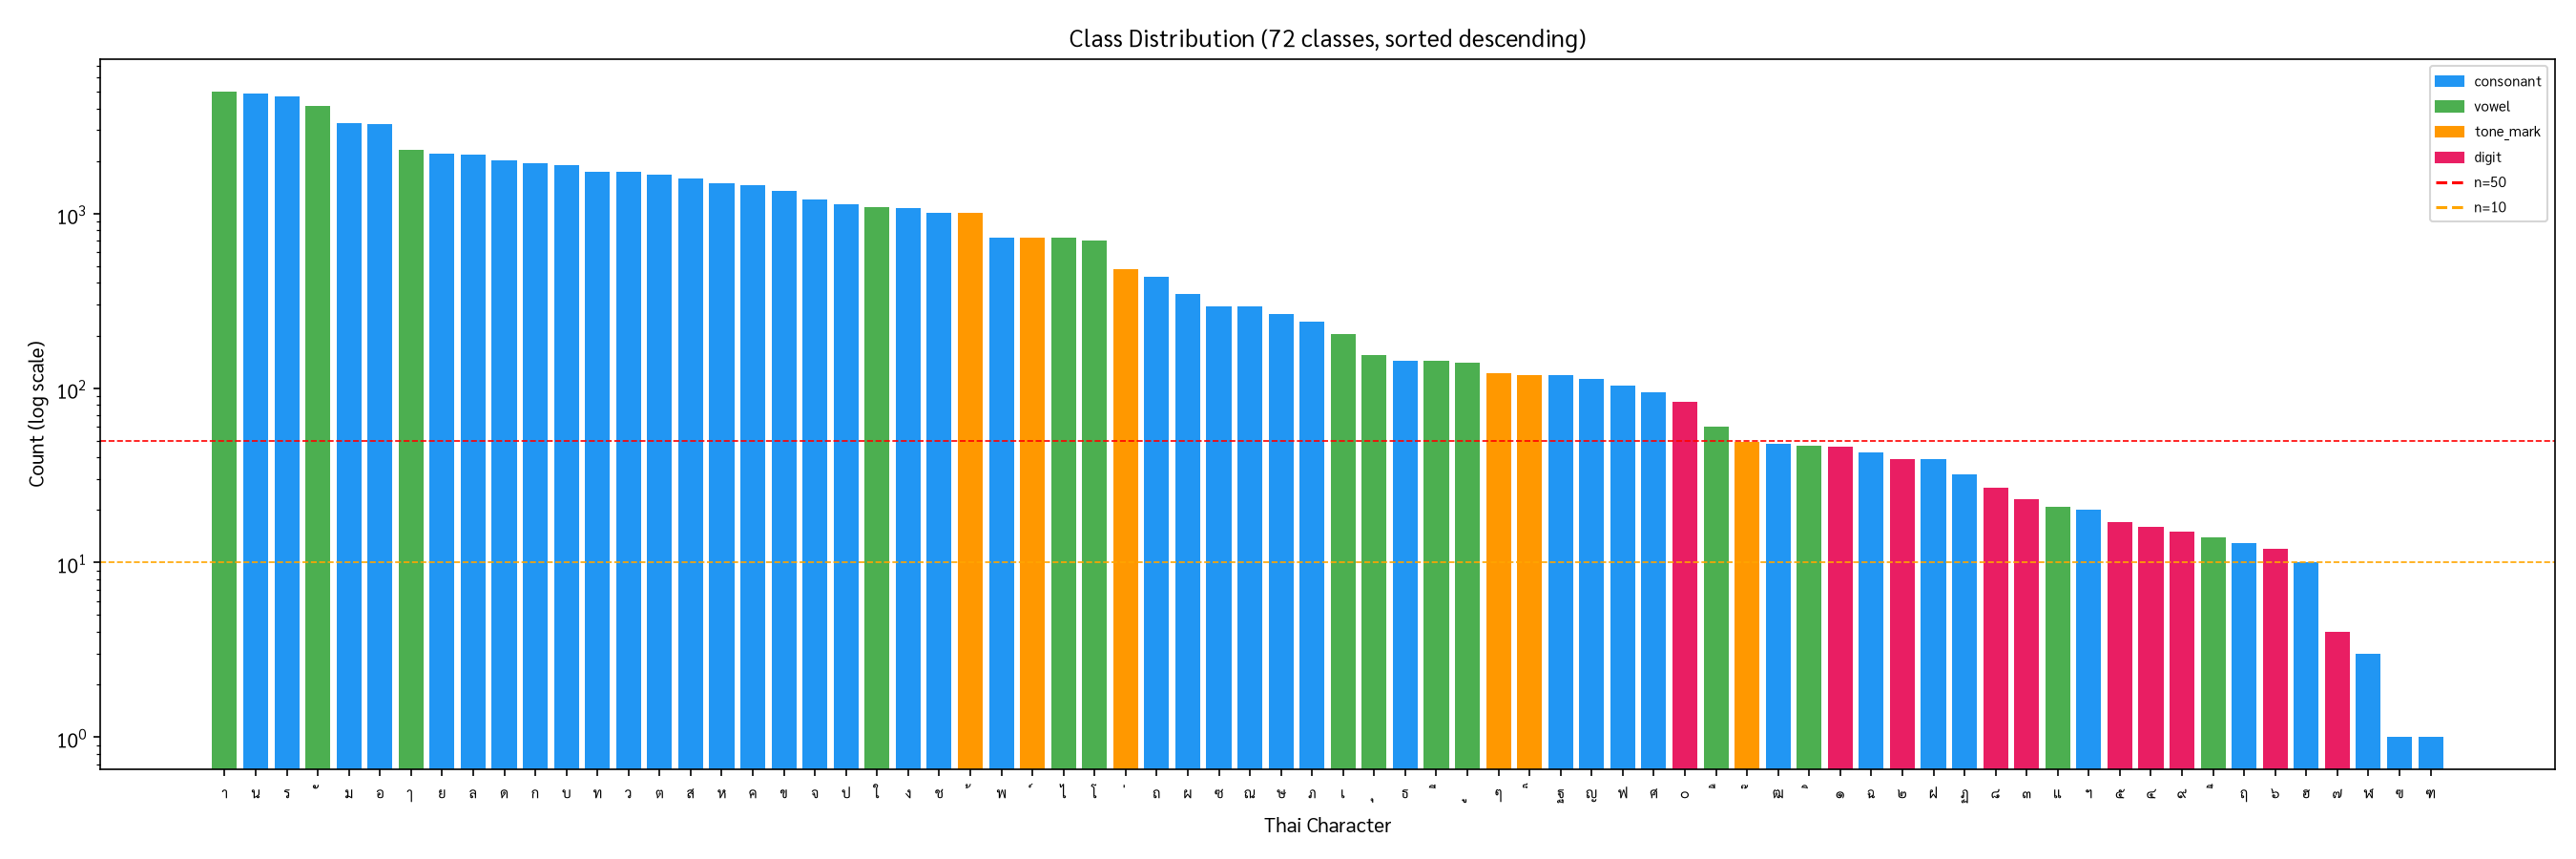


Displaying class_montage.png:


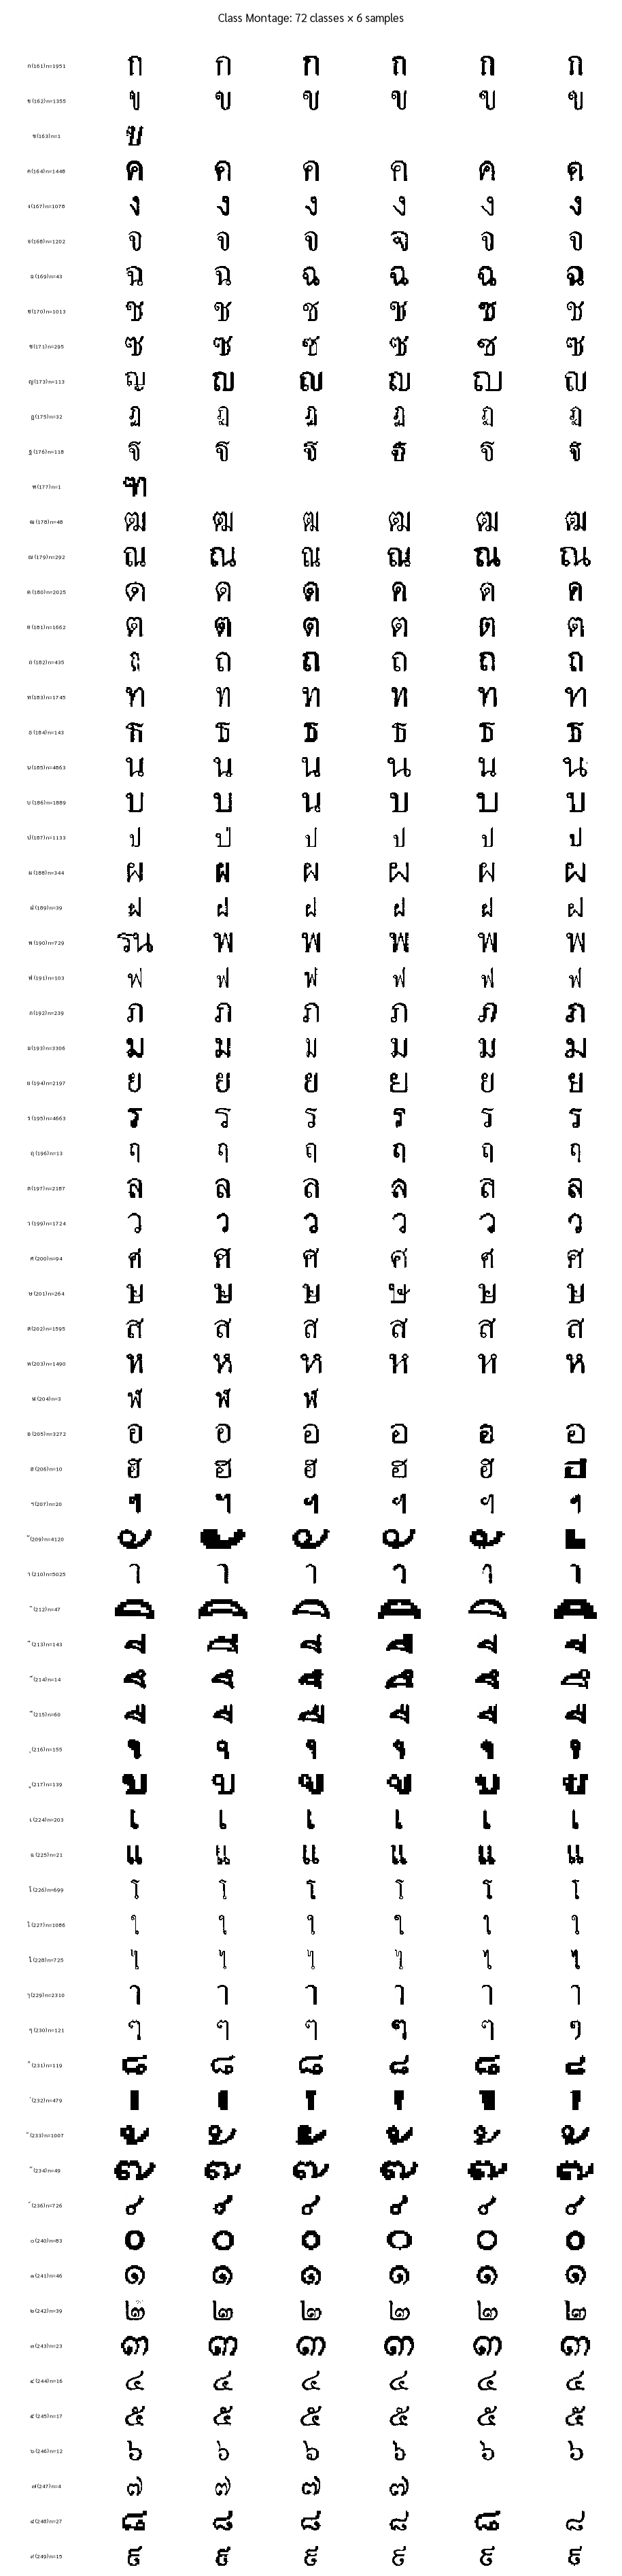

In [3]:
import zipfile
import subprocess
import pandas as pd
from tabulate import tabulate
from IPython.display import Image as IPImage, display

from thaichar.classes import CLASS_CODES, code_to_char, category

# 1. Unzip DATA_ZIP if DATA_DIR/round2 is missing
round2_dir = DATA_DIR / "round2"
if not round2_dir.exists() and (DATA_DIR / "ThaiCharacter Dataset" / "round2").exists():
    round2_dir = DATA_DIR / "ThaiCharacter Dataset" / "round2"

if not round2_dir.exists() and DATA_ZIP.exists():
    print(f"Unpacking {DATA_ZIP} into {DATA_DIR} via Python zipfile...")
    # Mention Windows zip extractor bug:
    # Windows native extractor can corrupt UTF-8 Thai filenames or create nested backslashes.
    print("Notice: Using Python's zipfile module preserves cross-platform path separators and UTF-8 encoding.")
    with zipfile.ZipFile(DATA_ZIP, "r") as zf:
        zf.extractall(DATA_DIR)
    if not round2_dir.exists() and (DATA_DIR / "ThaiCharacter Dataset" / "round2").exists():
        round2_dir = DATA_DIR / "ThaiCharacter Dataset" / "round2"
    print(f"✓ Extracted dataset. round2 location: {round2_dir}")
elif not round2_dir.exists():
    print(f"Notice: Raw image folder '{round2_dir}' not found.")
    if MODE == "inference":
        print("✓ Running in inference mode: raw dataset is optional when using pre-computed cache or shipped weights.")
    else:
        print("Warning: Training requires raw dataset images or pre-generated splits/cache.")

# 2. Count files per class into a 72-row table and assert 62,707 total
VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp"}
IGNORE_FILES = {".DS_Store", "Thumbs.db"}

class_count_rows = []
total_files = 0

if round2_dir.exists():
    for code in CLASS_CODES:
        c_dir = round2_dir / code
        if c_dir.is_dir():
            files = [f for f in c_dir.iterdir() if f.suffix.lower() in VALID_EXTS and f.name not in IGNORE_FILES]
            cnt = len(files)
        else:
            cnt = 0
        total_files += cnt
        class_count_rows.append({
            "code": code,
            "char": code_to_char(code),
            "category": category(code),
            "count": cnt,
        })
elif (PROJECT_DIR / "reports" / "eda" / "class_stats.csv").exists():
    stats_df = pd.read_csv(PROJECT_DIR / "reports" / "eda" / "class_stats.csv")
    for _, r in stats_df.iterrows():
        # column is 'n_files' in actual EDA output; fall back gracefully
        cnt = int(r.get("count", r.get("n_files", 0)))
        total_files += cnt
        class_count_rows.append({
            "code": r["code"],
            "char": code_to_char(r["code"]),
            "category": category(r["code"]),
            "count": cnt,
        })
else:
    print("Notice: No raw directory or class_stats.csv found to tabulate per-class raw file counts.")

if class_count_rows:
    count_df = pd.DataFrame(class_count_rows)
    print(f"\n--- Per-Class File Counts (72 Classes, Total: {total_files:,}) ---")
    print(tabulate(count_df.head(10), headers="keys", tablefmt="github", showindex=False))
    print(f"... ({len(count_df)} classes total) ...\n")
    
    # Assert 62,707 total (warn, don't crash, if different)
    EXPECTED_TOTAL = 62707
    if total_files != EXPECTED_TOTAL:
        print(f"WARNING: Total file count ({total_files:,}) differs from expected {EXPECTED_TOTAL:,}.")
    else:
        print(f"✓ Total raw file count matches expected: {total_files:,} images.")

# 3. Run scripts/eda.py + scripts/prep_data.py ONLY if data/splits/split_seed42.csv is missing
split_file = DATA_DIR / "splits" / "split_seed42.csv"
if not split_file.exists():
    print(f"Split file {split_file} is missing. Running EDA and data preparation scripts...")
    files_csv = PROJECT_DIR / "reports" / "eda" / "files.csv"
    if not files_csv.exists() and round2_dir.exists():
        print("Running scripts/eda.py...")
        subprocess.run(
            [sys.executable, str(PROJECT_DIR / "scripts" / "eda.py"), "--data", str(round2_dir), "--out", str(PROJECT_DIR / "reports" / "eda")],
            check=True,
        )
    print("Running scripts/prep_data.py...")
    subprocess.run([sys.executable, str(PROJECT_DIR / "scripts" / "prep_data.py")], cwd=str(PROJECT_DIR), check=True)
    print("✓ Data preparation complete.")
else:
    print(f"✓ Split file already present: {split_file}. Skipping EDA and prep_data.")

# 4. Show class-distribution + montage images if present
for img_file in ["class_distribution.png", "class_montage.png"]:
    img_path = PROJECT_DIR / "reports" / "eda" / img_file
    if img_path.exists():
        print(f"\nDisplaying {img_file}:")
        display(IPImage(filename=str(img_path)))


## 4. Model Training
This section runs training when `MODE == "train"` (skipped entirely when `MODE == "inference"`). It loads `FINAL_CONFIG`, applies runtime overrides (`seed`, `epochs`, `device`), calls `train_one(cfg)`, reports summary metrics, plots learning curves from `log.csv`, copies `best.pt` to `WEIGHTS_PATH`, and includes an optional cell for a 3-seed evaluation loop (`RUN_SEEDS = [42, 0, 1]`).


In [4]:
import yaml
import shutil
import matplotlib.pyplot as plt
import pandas as pd
from thaichar.engine import train_one

if MODE == "train":
    print("=" * 60)
    print("Executing Training Pipeline")
    print("=" * 60)
    
    # Load winning config YAML
    with open(FINAL_CONFIG, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    
    # Apply overrides
    cfg["seed"] = int(SEED)
    if EPOCHS_OVERRIDE is not None:
        cfg["epochs"] = int(EPOCHS_OVERRIDE)
    cfg["device"] = "cuda" if torch.cuda.is_available() else "cpu"
    cfg["split_file"] = str(DATA_DIR / "splits" / "split_seed42.csv")
    cfg["cache"] = str(DATA_DIR / "cache" / "glyphs.npz")
    cfg["out_root"] = str(PROJECT_DIR / "runs")
    
    print(f"Training Exp ID:    {cfg.get('exp_id')}")
    print(f"Model Architecture: {cfg.get('model')}")
    print(f"Epochs:             {cfg.get('epochs')}")
    print(f"Target Device:      {cfg.get('device')}")
    print(f"Augmentation:       {cfg.get('aug')}")
    
    # Call training engine
    train_metrics = train_one(cfg)
    
    print("\n--- Training Completed Successfully ---")
    print(f"Top-1 Accuracy:     {train_metrics.get('top1', 0.0)*100:.2f}%")
    print(f"Balanced Accuracy:  {train_metrics.get('balanced_acc', 0.0)*100:.2f}%")
    print(f"Macro-F1 Score:     {train_metrics.get('macro_f1', 0.0)*100:.2f}%")
    print(f"Minority Accuracy:  {train_metrics.get('minority_acc', 0.0)*100:.2f}%")
    
    # Copy best.pt to WEIGHTS_PATH
    exp_dir = PROJECT_DIR / "runs" / str(cfg.get("exp_id"))
    best_ckpt = exp_dir / "best.pt"
    if best_ckpt.exists():
        WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(best_ckpt, WEIGHTS_PATH)
        print(f"✓ Copied best checkpoint ({best_ckpt}) to {WEIGHTS_PATH}")
    
    # Plot log.csv training curves
    log_file = exp_dir / "log.csv"
    if log_file.exists():
        log_df = pd.read_csv(log_file)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        
        # Loss curve
        axes[0].plot(log_df["epoch"], log_df["train_loss"], "o-", label="Train Loss", color="#1f77b4")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Cross-Entropy Loss")
        axes[0].set_title("Training Loss")
        axes[0].grid(True, linestyle=":", alpha=0.6)
        axes[0].legend()
        
        # Accuracy curves
        axes[1].plot(log_df["epoch"], log_df["train_acc"], "o--", label="Train Acc", color="#2ca02c")
        axes[1].plot(log_df["epoch"], log_df["val_top1"], "s-", label="Val Top-1", color="#ff7f0e")
        axes[1].plot(log_df["epoch"], log_df["val_bal_acc"], "^-", label="Val Bal Acc", color="#d62728")
        if "ema_val_bal_acc" in log_df.columns:
            axes[1].plot(log_df["epoch"], log_df["ema_val_bal_acc"], "d-.", label="EMA Val Bal Acc", color="#9467bd")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_title("Accuracy Curves")
        axes[1].grid(True, linestyle=":", alpha=0.6)
        axes[1].legend()
        
        plt.tight_layout()
        train_curve_path = OUTPUT_DIR / "training_curves.png"
        plt.savefig(train_curve_path, dpi=150)
        plt.show()
        plt.close()
        print(f"✓ Saved training curves to {train_curve_path}")
else:
    print("Notice: MODE is set to 'inference'. Training skipped.")


Notice: MODE is set to 'inference'. Training skipped.


In [5]:
# Optional cell: 3-seed training loop collecting mean ± std
RUN_3_SEEDS = False  # Set to True to execute multi-seed evaluation
RUN_SEEDS = [42, 0, 1]

if MODE == "train" and RUN_3_SEEDS:
    import copy
    import numpy as np
    
    multi_metrics = []
    for s in RUN_SEEDS:
        print(f"\n>>> Running Seed {s} ({RUN_SEEDS.index(s)+1}/{len(RUN_SEEDS)}) <<<")
        seed_cfg = copy.deepcopy(cfg)
        seed_cfg["seed"] = s
        seed_cfg["exp_id"] = f"{cfg.get('exp_id', 'run')}_seed{s}"
        seed_cfg["split_file"] = str(DATA_DIR / "splits" / f"split_seed{s}.csv")
        m = train_one(seed_cfg)
        multi_metrics.append({
            "seed": s,
            "top1": m.get("top1", 0.0),
            "balanced_acc": m.get("balanced_acc", 0.0),
            "macro_f1": m.get("macro_f1", 0.0),
            "minority_acc": m.get("minority_acc", 0.0),
        })
    
    res_df = pd.DataFrame(multi_metrics)
    print("\n" + "=" * 60)
    print("Multi-Seed Training Results (Mean ± Std)")
    print("=" * 60)
    for col in ["top1", "balanced_acc", "macro_f1", "minority_acc"]:
        vals = res_df[col].values
        print(f"{col:<15}: {vals.mean()*100:.2f}% ± {vals.std()*100:.2f}%")
else:
    print("3-seed training loop skipped (set RUN_3_SEEDS = True in train mode to run).")


3-seed training loop skipped (set RUN_3_SEEDS = True in train mode to run).


## 5. Model Evaluation
This section loads the checkpoint from `WEIGHTS_PATH`, evaluates on both the stratified validation split and the document-disjoint split, reports key metrics (top-1, balanced accuracy, macro-F1, minority accuracy), evaluates a tau sweep (logit adjustment), renders the 72x72 confusion matrix using Sarabun Thai font (`assets/fonts/Sarabun-Regular.ttf`), and tabulates the top-20 confused character pairs.


✓ Registered Thai font: Sarabun (/home/eggchad/eakject/research/Deep_Man/Deep_CNN/assets/fonts/Sarabun-Regular.ttf)


✓ Checkpoint loaded successfully from: /home/eggchad/eakject/research/Deep_Man/Deep_CNN/runs/A1_resnet18_full_64_T4/best.pt
  Model: resnet18, Image Size: 64, Channels: gray3


Checkpoint was trained on split_kind='strat' -> evaluating on that partition's val only.



--- Stratified Validation Split (80:20, seed 42) (N = 12,027) ---
Top-1 Accuracy:     97.53%
Balanced Accuracy:  97.94%
Macro-F1 Score:     97.70%
Minority Accuracy:  96.67% (Classes with n_train < 50)
Tau Sweep (Logit Adjustment):
  tau=0.0  -> Top-1: 97.53%, Bal Acc: 97.94%, Macro-F1: 97.70%
  tau=0.25 -> Top-1: 97.61%, Bal Acc: 97.97%, Macro-F1: 97.32%
  tau=0.5  -> Top-1: 97.56%, Bal Acc: 97.93%, Macro-F1: 96.28%
  tau=0.75 -> Top-1: 96.99%, Bal Acc: 97.54%, Macro-F1: 95.40%


findfont: Failed to find font weight bold for Sarabun, now using 400.


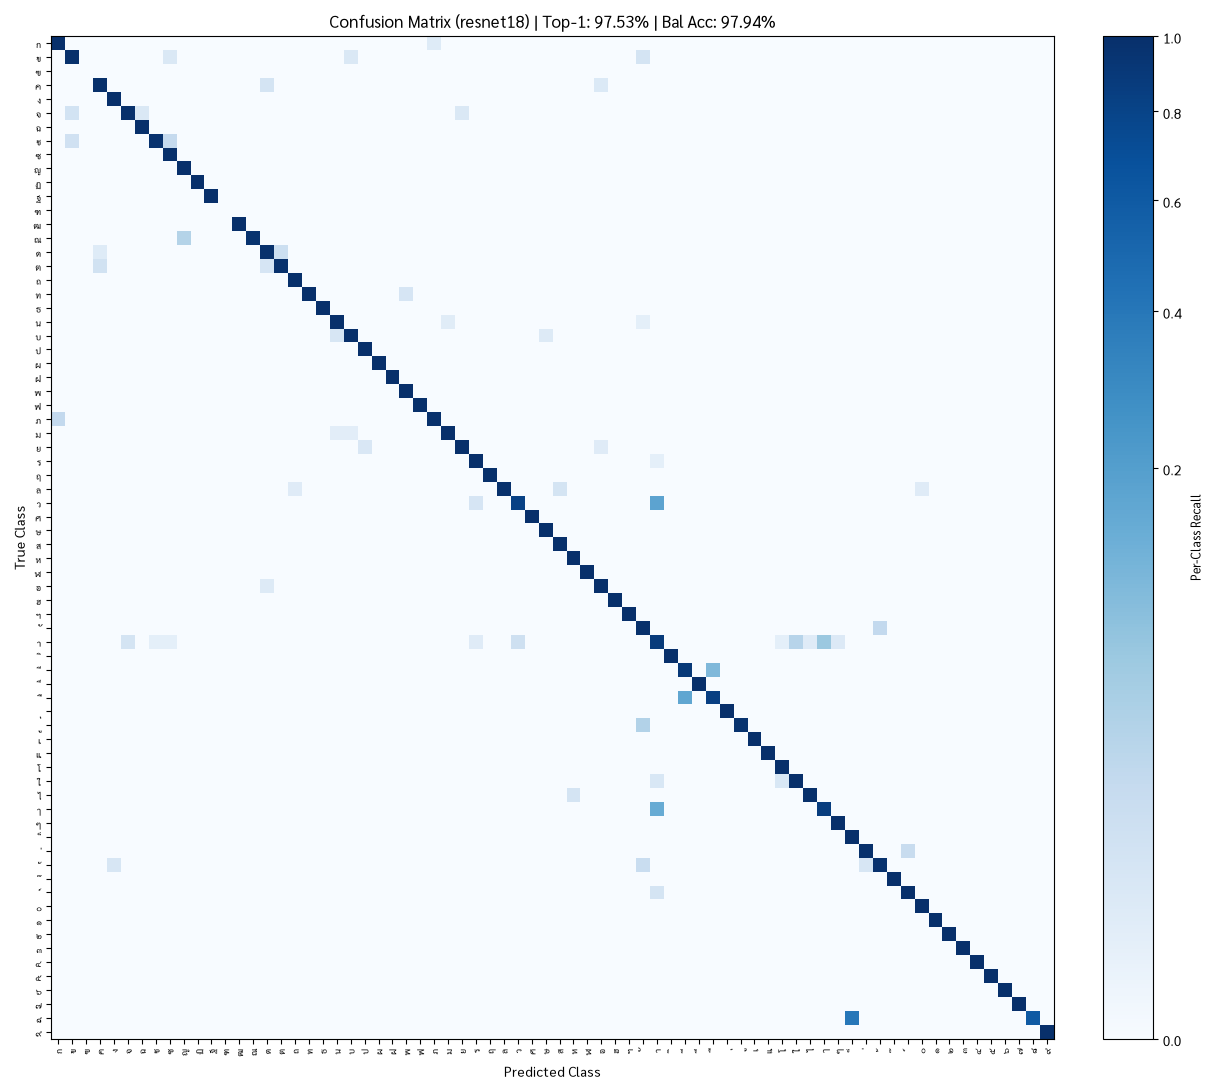

✓ Saved confusion matrix figure to /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs/confusion_matrix.png

--- Top-20 Confused Pairs ---
|    | True Glyph   | Pred Glyph   |   Errors | % of True   |   n_train (True) |
|----|--------------|--------------|----------|-------------|------------------|
|  1 | ว (199)      | า (210)      |       59 | 17.56%      |             1342 |
|  2 | า (210)      | ๅ (229)      |       57 | 6.28%       |             3630 |
|  3 | ๅ (229)      | า (210)      |       38 | 14.62%      |             1041 |
|  4 | า (210)      | ใ (227)      |       28 | 3.09%       |             3630 |
|  5 | ั (209)       | ้ (233)       |       16 | 2.17%       |             2950 |
|  6 | า (210)      | ว (199)      |       10 | 1.10%       |             3630 |
|  7 | า (210)      | จ (168)      |        6 | 0.66%       |             3630 |
|  8 | ด (180)      | ต (181)      |        5 | 1.24%       |             1613 |
|  9 | ช (170)      | ซ (171)      |        

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from tabulate import tabulate

from thaichar.infer import load_checkpoint
from thaichar.engine import pick_device, predict
from thaichar.data import ThaiGlyphDataset, load_cache
from thaichar.metrics import compute_metrics, tau_sweep
from thaichar.classes import CLASS_CODES, CLASS_CHARS, code_to_char

# 1. Register Thai Font (Sarabun)
font_path = PROJECT_DIR / "assets" / "fonts" / "Sarabun-Regular.ttf"
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    prop = font_manager.FontProperties(fname=str(font_path))
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["axes.unicode_minus"] = False
    print(f"✓ Registered Thai font: {prop.get_name()} ({font_path})")
else:
    print("Notice: Sarabun font not found, falling back to system sans-serif.")

# 2. Load Checkpoint
if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at WEIGHTS_PATH: {WEIGHTS_PATH}. Train a model or provide weights.")

eval_device = pick_device("auto")
eval_model, ckpt_cfg = load_checkpoint(WEIGHTS_PATH, device=eval_device)
print(f"✓ Checkpoint loaded successfully from: {WEIGHTS_PATH}")
print(f"  Model: {ckpt_cfg.get('model')}, Image Size: {ckpt_cfg.get('img_size')}, Channels: {ckpt_cfg.get('channel_mode')}")

# Resolve dataset paths
eval_split_file = Path(ckpt_cfg.get("split_file", "data/splits/split_seed42.csv"))
if not eval_split_file.is_absolute():
    eval_split_file = PROJECT_DIR / eval_split_file
if not eval_split_file.exists():
    eval_split_file = DATA_DIR / "splits" / "split_seed42.csv"

eval_cache_path = Path(ckpt_cfg.get("cache", "data/cache/glyphs.npz"))
if not eval_cache_path.is_absolute():
    eval_cache_path = PROJECT_DIR / eval_cache_path
if not eval_cache_path.exists():
    eval_cache_path = DATA_DIR / "cache" / "glyphs.npz"

eval_splits_df = pd.read_csv(eval_split_file)
cache_dict = load_cache(str(eval_cache_path))

# Prepare train counts and priors
train_df = eval_splits_df[eval_splits_df["split"] == "train"].reset_index(drop=True)
class_counts_train = np.bincount(train_df["label"].values, minlength=72)
train_priors = class_counts_train / class_counts_train.sum()
log_priors = np.log(np.maximum(train_priors, 1e-12))

# 3. Evaluate ONLY on the validation split the checkpoint was trained against.
#    The stratified and document-disjoint partitions overlap (a strat-trained model has seen ~80% of the
#    doc-val images), so evaluating a model on the *other* partition would report training accuracy.
_trained_split = ckpt_cfg.get("split_kind", "strat")
_split_table = {"strat": ("strat", "split", "Stratified Validation Split (80:20, seed 42)"),
                "doc": ("doc", "doc_split", "Document-Disjoint Validation Split (4 held-out documents)")}
print(f"Checkpoint was trained on split_kind='{_trained_split}' -> evaluating on that partition's val only.")
eval_results = {}
for split_key, col_name, split_name in [_split_table[_trained_split]]:
    val_subset = eval_splits_df[eval_splits_df[col_name] == "val"].reset_index(drop=True)
    val_ds = ThaiGlyphDataset(
        val_subset,
        cache_dict,
        size=int(ckpt_cfg.get("img_size", 64)),
        channel_mode=ckpt_cfg.get("channel_mode", "gray3"),
        transform=None,
        margin=float(ckpt_cfg.get("margin", 0.1)),
    )
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)
    logits, y_true = predict(eval_model, val_loader, eval_device)
    m = compute_metrics(y_true, logits, class_counts_train)
    sweep = tau_sweep(logits, y_true, log_priors, class_counts_train, taus=(0.0, 0.25, 0.5, 0.75))
    eval_results[split_key] = {"metrics": m, "sweep": sweep, "logits": logits, "y_true": y_true}
    
    print(f"\n--- {split_name} (N = {len(val_subset):,}) ---")
    print(f"Top-1 Accuracy:     {m['top1']*100:.2f}%")
    print(f"Balanced Accuracy:  {m['balanced_acc']*100:.2f}%")
    print(f"Macro-F1 Score:     {m['macro_f1']*100:.2f}%")
    print(f"Minority Accuracy:  {m['minority_acc']*100:.2f}% (Classes with n_train < 50)")
    print("Tau Sweep (Logit Adjustment):")
    for t_val, s_m in sweep.items():
        print(f"  tau={t_val:<4} -> Top-1: {s_m['top1']*100:.2f}%, Bal Acc: {s_m['balanced_acc']*100:.2f}%, Macro-F1: {s_m['macro_f1']*100:.2f}%")

# 4. Confusion Matrix (Stratified Split)
strat_m = eval_results[_trained_split]["metrics"]
cm = np.array(strat_m["confusion"], dtype=float)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.zeros_like(cm)
np.divide(cm, row_sums, out=cm_norm, where=row_sums > 0)

fig, ax = plt.subplots(figsize=(13, 11))
norm = mcolors.PowerNorm(gamma=0.35, vmin=0.0, vmax=1.0)
im = ax.imshow(cm_norm, cmap="Blues", norm=norm, interpolation="nearest")

ax.set_xticks(range(72))
ax.set_yticks(range(72))
ax.set_xticklabels(CLASS_CHARS, fontsize=6.5, rotation=90)
ax.set_yticklabels(CLASS_CHARS, fontsize=6.5)
ax.set_xlabel("Predicted Class", fontsize=10)
ax.set_ylabel("True Class", fontsize=10)
ax.set_title(
    f"Confusion Matrix ({ckpt_cfg.get('model')}) | Top-1: {strat_m['top1']*100:.2f}% | Bal Acc: {strat_m['balanced_acc']*100:.2f}%",
    fontsize=12,
    fontweight="bold",
)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Per-Class Recall", fontsize=9)
plt.tight_layout()
cm_plot_path = OUTPUT_DIR / "confusion_matrix.png"
fig.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"✓ Saved confusion matrix figure to {cm_plot_path}")

# 5. Top-20 Confused Pairs Table
confused = []
raw_cm = np.array(strat_m["confusion"], dtype=int)
for i in range(72):
    for j in range(72):
        if i != j and raw_cm[i, j] > 0:
            c_val = raw_cm[i, j]
            tot_true = int(raw_cm[i].sum())
            pct = (c_val / tot_true * 100.0) if tot_true > 0 else 0.0
            confused.append({
                "True Glyph": f"{CLASS_CHARS[i]} ({CLASS_CODES[i]})",
                "Pred Glyph": f"{CLASS_CHARS[j]} ({CLASS_CODES[j]})",
                "Errors": c_val,
                "% of True": f"{pct:.2f}%",
                "n_train (True)": int(class_counts_train[i]),
            })

confused.sort(key=lambda x: (x["Errors"], float(x["% of True"].rstrip("%"))), reverse=True)
top20_df = pd.DataFrame(confused[:20])
print("\n--- Top-20 Confused Pairs ---")
print(tabulate(top20_df, headers="keys", tablefmt="github", showindex=range(1, min(21, len(top20_df) + 1))))


## 6. Inference Demonstration
This section demonstrates real-world inference with `predict_topk`:
1. Prediction on 12 random glyphs from the validation split comparing true vs predicted class with confidence.
2. File upload interface via `google.colab.files.upload()` with local path fallback.
3. Interactive user interface: tries **Gradio** (`gr.Interface`), falling back gracefully to **ipywidgets**.
4. Latency profiling per image (ms) and model parameter / disk footprint summary.


findfont: Failed to find font weight bold for Sarabun, now using 400.


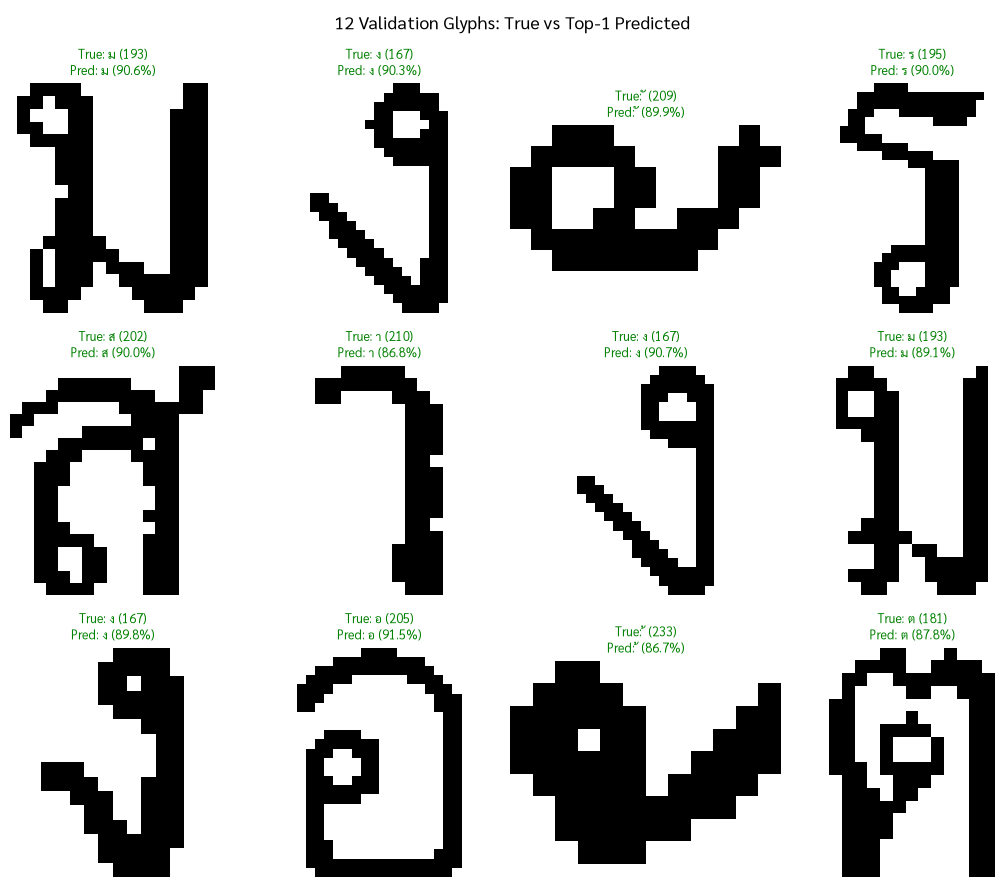

✓ Saved 12-glyph inference demo to /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs/val_inference_12.png
Notice: Colab file upload bypassed or running in headless mode (No module named 'google').
Using random validation sample as fallback image for demo.
Fallback Predictions: [('ม', 193, '90.6%'), ('บ', 186, '0.3%'), ('น', 185, '0.2%'), ('ษ', 201, '0.2%'), ('ธ', 184, '0.2%')]
Notice: Gradio interface not launched (No module named 'gradio'). Trying ipywidgets...
ipywidgets fallback notice: No module named 'ipywidgets'



Model Profiling & Specifications
Single-image Latency: 10.24 ms (cpu)
Total Parameters:     11,213,448 (11.21M)
Trainable Parameters: 11,213,448 (11.21M)
Checkpoint Disk Size: 42.85 MB


In [7]:
import io
import time
from PIL import Image
from thaichar.infer import predict_topk, preprocess_image
from thaichar.models import count_params

# GlyphCache uses integer indices — build a path→index mapping once
_cache_path_to_idx = {p: i for i, p in enumerate(cache_dict.paths)}

def _get_glyph(path_str):
    """Look up a glyph canvas from the cache by path string."""
    idx = _cache_path_to_idx.get(path_str)
    if idx is not None:
        return cache_dict[idx]
    return None

# (a) 12 random val glyphs with true vs predicted
strat_val_df = eval_splits_df[eval_splits_df["split"] == "val"].reset_index(drop=True)
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(strat_val_df), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(11, 9))
for idx, ax in zip(sample_indices, axes.flatten()):
    row = strat_val_df.iloc[idx]
    glyph_canvas = _get_glyph(row["path"])
    true_char = row["char"]
    true_code = row["code"]
    
    if glyph_canvas is None:
        ax.axis("off")
        continue
    preds = predict_topk(eval_model, ckpt_cfg, glyph_canvas, k=3)
    top_char, top_code, top_prob = preds[0]
    is_correct = (top_code == true_code)
    
    ax.imshow(glyph_canvas, cmap="gray")
    color = "green" if is_correct else "red"
    ax.set_title(f"True: {true_char} ({true_code})\nPred: {top_char} ({top_prob*100:.1f}%)", color=color, fontsize=9)
    ax.axis("off")

plt.suptitle("12 Validation Glyphs: True vs Top-1 Predicted", fontsize=13, fontweight="bold")
plt.tight_layout()
val_demo_path = OUTPUT_DIR / "val_inference_12.png"
plt.savefig(val_demo_path, dpi=150)
plt.show()
plt.close(fig)
print(f"✓ Saved 12-glyph inference demo to {val_demo_path}")

# (b) Uploaded files via google.colab.files.upload() guarded by try/except
uploaded = {}
try:
    from google.colab import files
    print("Upload an image (PNG/JPG) of a Thai character to classify:")
    uploaded = files.upload()
except Exception as e:
    print(f"Notice: Colab file upload bypassed or running in headless mode ({e}).")

if uploaded:
    print(f"Processing {len(uploaded)} uploaded image(s):")
    for name, data in uploaded.items():
        pil_img = Image.open(io.BytesIO(data))
        preds = predict_topk(eval_model, ckpt_cfg, pil_img, k=5)
        print(f"\nPredictions for {name}:")
        for rank, (char, code, prob) in enumerate(preds, 1):
            print(f"  {rank}. {char} ({code}): {prob*100:.2f}%")
else:
    print("Using random validation sample as fallback image for demo.")
    sample_img = _get_glyph(strat_val_df.iloc[sample_indices[0]]["path"])
    if sample_img is not None:
        preds = predict_topk(eval_model, ckpt_cfg, sample_img, k=5)
        print(f"Fallback Predictions: {[(c, cd, f'{p*100:.1f}%') for c, cd, p in preds]}")

# (c) Gradio / ipywidgets interface
def classify_thai_char(img):
    if img is None:
        return {}
    top_preds = predict_topk(eval_model, ckpt_cfg, img, k=5)
    return {f"{c} ({cd})": float(p) for c, cd, p in top_preds}

gradio_launched = False
try:
    import gradio as gr
    demo = gr.Interface(
        fn=classify_thai_char,
        inputs=gr.Image(type="pil", label="Thai Glyph Image"),
        outputs=gr.Label(num_top_classes=5, label="Top-5 Predictions"),
        title="Thai Character 72-Class Classifier",
        description="Upload an image of a Thai handwritten character.",
    )
    demo.launch(share=False)
    gradio_launched = True
    print("✓ Gradio interface launched successfully.")
except Exception as e:
    print(f"Notice: Gradio interface not launched ({e}). Trying ipywidgets...")

if not gradio_launched:
    try:
        import ipywidgets as widgets
        from IPython.display import display
        
        uploader = widgets.FileUpload(accept="image/*", multiple=False)
        widget_out = widgets.Output()
        
        def handle_widget_upload(change):
            with widget_out:
                widget_out.clear_output()
                for fn, file_data in uploader.value.items():
                    content = file_data["content"] if isinstance(file_data, dict) else file_data.content
                    p_img = Image.open(io.BytesIO(content))
                    display(p_img)
                    p_list = predict_topk(eval_model, ckpt_cfg, p_img, k=5)
                    for rank, (c, cd, pr) in enumerate(p_list, 1):
                        print(f"  {rank}. {c} ({cd}): {pr*100:.2f}%")
        
        uploader.observe(handle_widget_upload, names="value")
        print("ipywidgets FileUpload Interface:")
        display(uploader, widget_out)
    except Exception as e:
        print(f"ipywidgets fallback notice: {e}")

# Latency and model size metrics
dummy_canvas = np.full((64, 64), 255, dtype=np.uint8)
dummy_canvas[20:44, 20:44] = 0
x_ten, g_ten = preprocess_image(dummy_canvas, ckpt_cfg)
x_ten = x_ten.to(eval_device)
g_ten = g_ten.to(eval_device) if g_ten is not None else None

# Warmup
for _ in range(10):
    with torch.no_grad():
        _ = eval_model(x_ten, g_ten if ckpt_cfg.get("geometry", False) else None)
if eval_device.type == "cuda":
    torch.cuda.synchronize()

t_start = time.perf_counter()
n_bench = 50
for _ in range(n_bench):
    with torch.no_grad():
        _ = eval_model(x_ten, g_ten if ckpt_cfg.get("geometry", False) else None)
if eval_device.type == "cuda":
    torch.cuda.synchronize()
lat_ms = (time.perf_counter() - t_start) / n_bench * 1000.0

p_total, p_train = count_params(eval_model)
ckpt_mb = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024) if WEIGHTS_PATH.exists() else 0.0

print("\n" + "=" * 60)
print("Model Profiling & Specifications")
print("=" * 60)
print(f"Single-image Latency: {lat_ms:.2f} ms ({eval_device})")
print(f"Total Parameters:     {p_total:,} ({p_total/1e6:.2f}M)")
print(f"Trainable Parameters: {p_train:,} ({p_train/1e6:.2f}M)")
print(f"Checkpoint Disk Size: {ckpt_mb:.2f} MB")


## 7. Robustness Quick Check
This section runs `scripts/robustness.py` with `--limit 5` samples per class on the model weights to evaluate corruption tolerance (rotation, thickening, thinning, salt & pepper, occlusions, blurs) and displays the resulting `curves.png`.


Running scripts/robustness.py with --limit 5...


✓ Robustness evaluation completed successfully.

Displaying /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs/robustness/curves.png:


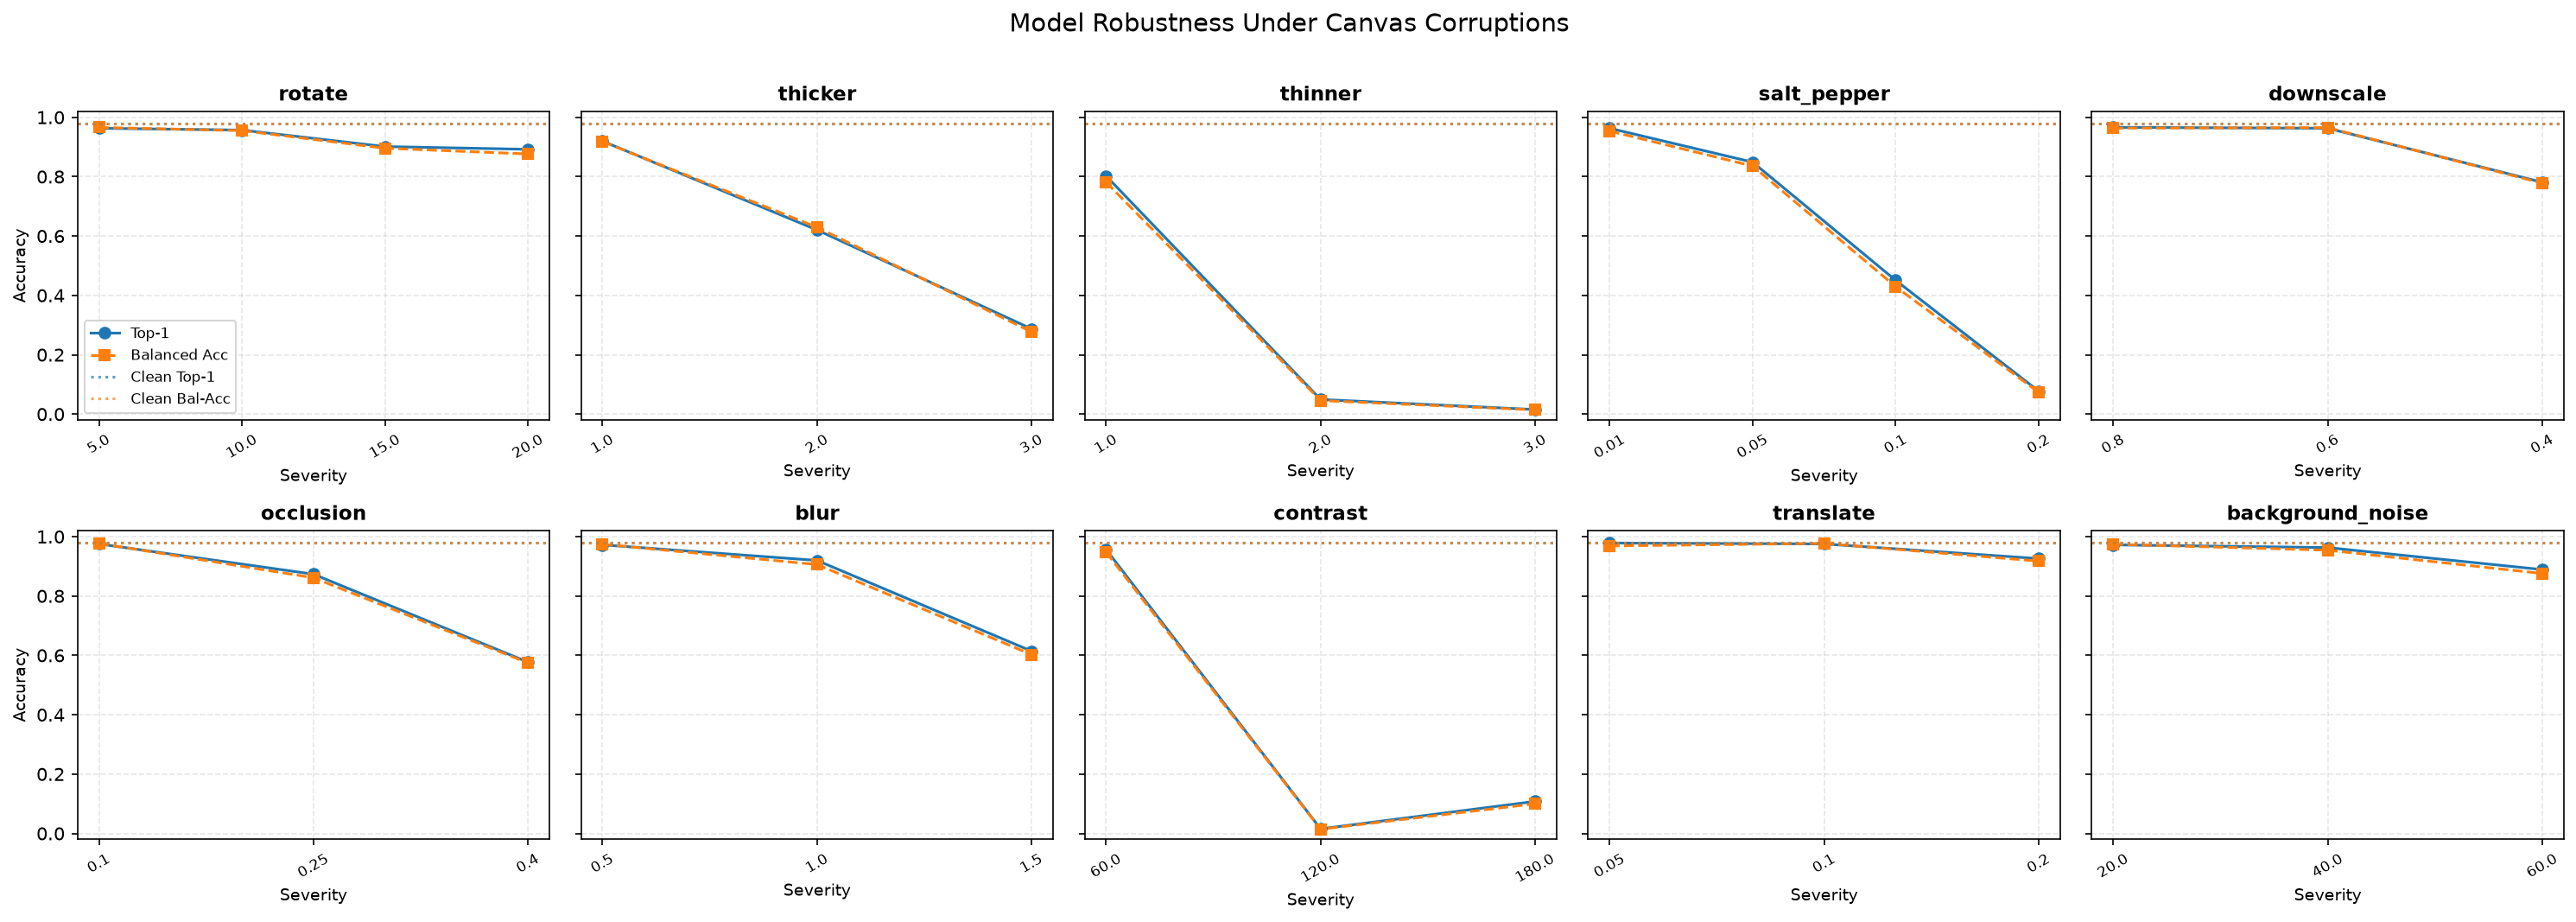

In [8]:
import subprocess
from IPython.display import Image as IPImage, display

robust_dir = OUTPUT_DIR / "robustness"
robust_dir.mkdir(parents=True, exist_ok=True)

print("Running scripts/robustness.py with --limit 5...")
robust_cmd = [
    sys.executable,
    str(PROJECT_DIR / "scripts" / "robustness.py"),
    "--ckpt", str(WEIGHTS_PATH),
    "--limit", "5",
    "--out", str(robust_dir),
    "--device", "auto",
]
proc = subprocess.run(robust_cmd, capture_output=True, text=True)
if proc.returncode == 0:
    print("✓ Robustness evaluation completed successfully.")
else:
    print(f"Notice: Robustness script exit code {proc.returncode}.")
    if proc.stderr:
        print(f"Stderr: {proc.stderr[-500:]}")

robust_plot = robust_dir / "curves.png"
if robust_plot.exists():
    print(f"\nDisplaying {robust_plot}:")
    display(IPImage(filename=str(robust_plot)))
else:
    print(f"Notice: {robust_plot} not generated.")


## 8. Export Metrics and Artifacts
This section packages key validation metrics, tau sweep scores, model specs, and paths into `metrics_summary.json` and copies all generated artifact figures to `OUTPUT_DIR` (and Google Drive if mounted).


In [9]:
import json
import shutil
from datetime import datetime

# Build exportable summary dict
summary = {
    "generated_at": datetime.now().isoformat(),
    "mode": MODE,
    "weights_path": str(WEIGHTS_PATH),
    "model_architecture": ckpt_cfg.get("model"),
    "img_size": int(ckpt_cfg.get("img_size", 64)),
    "params_total": p_total,
    "params_trainable": p_train,
    "checkpoint_size_mb": round(ckpt_mb, 2),
    "latency_ms": round(lat_ms, 2),
    "eval_device": str(eval_device),
    "stratified_val": {
        "top1": strat_m["top1"],
        "top5": strat_m["top5"],
        "balanced_acc": strat_m["balanced_acc"],
        "macro_f1": strat_m["macro_f1"],
        "minority_acc": strat_m["minority_acc"],
    },
    "evaluated_split": _trained_split,
    "tau_sweep": {
        str(k): {m_k: float(m_v) for m_k, m_v in v.items()}
        for k, v in eval_results[_trained_split]["sweep"].items()
    },
}

summary_json_path = OUTPUT_DIR / "metrics_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"✓ Saved summary report to {summary_json_path}")

# Copy to Google Drive if mounted
if USE_DRIVE:
    drive_out = Path("/content/drive/MyDrive/ThaiChar72_Outputs")
    try:
        drive_out.mkdir(parents=True, exist_ok=True)
        shutil.copy(summary_json_path, drive_out / "metrics_summary.json")
        for fig_name in ["confusion_matrix.png", "training_curves.png", "val_inference_12.png"]:
            src_f = OUTPUT_DIR / fig_name
            if src_f.exists():
                shutil.copy(src_f, drive_out / fig_name)
        if (OUTPUT_DIR / "robustness" / "curves.png").exists():
            shutil.copy(OUTPUT_DIR / "robustness" / "curves.png", drive_out / "robustness_curves.png")
        print(f"✓ All deliverables successfully copied to Google Drive at {drive_out}")
    except Exception as e:
        print(f"Notice: Failed to copy to Google Drive ({e})")

print("\n" + "=" * 60)
print("Deliverables Export Complete!")
print(f"Outputs stored in: {OUTPUT_DIR}")
print("=" * 60)


✓ Saved summary report to /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs/metrics_summary.json

Deliverables Export Complete!
Outputs stored in: /home/eggchad/eakject/research/Deep_Man/Deep_CNN/outputs
